In [1]:
!pip install timm albumentations grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import cv2
import timm
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [5]:
# =========================================================
# DATASET PATH
# =========================================================

DATASET_DIR = "/content/drive/MyDrive/deepfake"

In [6]:
# =========================================================
# LOAD DATAFRAME
# =========================================================

real_paths = []

fake_paths = []

# REAL
real_dir = os.path.join(
    DATASET_DIR,
    "Real"
)

for file in os.listdir(real_dir):

    real_paths.append({

        "path": os.path.join(
            real_dir,
            file
        ),

        "label": 0
    })

# FAKE
fake_dir = os.path.join(
    DATASET_DIR,
    "Fake"
)

for file in os.listdir(fake_dir):

    fake_paths.append({

        "path": os.path.join(
            fake_dir,
            file
        ),

        "label": 1
    })

df = pd.DataFrame(
    real_paths + fake_paths
)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(df.head())
print("\nTOTAL:",len(df))

                                                path  label
0     /content/drive/MyDrive/deepfake/Fake/532t.jpeg      1
1  /content/drive/MyDrive/deepfake/Real/Copy of d...      0
2  /content/drive/MyDrive/deepfake/Fake/v3_051491...      1
3  /content/drive/MyDrive/deepfake/Real/Copy of m...      0
4  /content/drive/MyDrive/deepfake/Fake/Face (84)...      1

TOTAL: 1046


In [7]:
# =========================================================
# DATASET STATISTICS
# =========================================================

print("="*50)

print("DATASET STATISTICS")

print("="*50)

print()

print("TOTAL IMAGES :", len(df))

print()

print(df["label"].value_counts())

print()

print("REAL IMAGES :",
      len(df[df.label == 0]))

print("FAKE IMAGES :",
      len(df[df.label == 1]))

DATASET STATISTICS

TOTAL IMAGES : 1046

label
1    632
0    414
Name: count, dtype: int64

REAL IMAGES : 414
FAKE IMAGES : 632


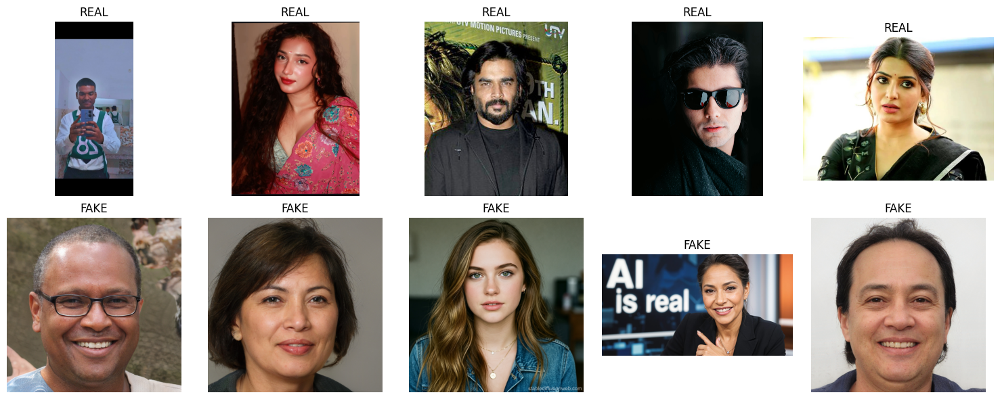

In [8]:
# =========================================================
# SHOW SAMPLE IMAGES
# =========================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

real_samples = df[
    df.label == 0
].sample(5)

fake_samples = df[
    df.label == 1
].sample(5)

# REAL
for i, (_, row) in enumerate(real_samples.iterrows()):

    img = cv2.imread(row.path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    axes[0,i].imshow(img)

    axes[0,i].set_title("REAL")

    axes[0,i].axis("off")

# FAKE
for i, (_, row) in enumerate(fake_samples.iterrows()):

    img = cv2.imread(row.path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    axes[1,i].imshow(img)

    axes[1,i].set_title("FAKE")

    axes[1,i].axis("off")

plt.tight_layout()

plt.show()

In [9]:
# =========================================================
# TRAIN / VAL SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(

    df,

    test_size=0.2,

    stratify=df["label"],

    random_state=42
)

print("TRAIN :", len(train_df))

print("VAL :", len(val_df))

TRAIN : 836
VAL : 210


In [10]:
print("TRAIN :", len(train_df))

print("VAL :", len(val_df))

TRAIN : 836
VAL : 210


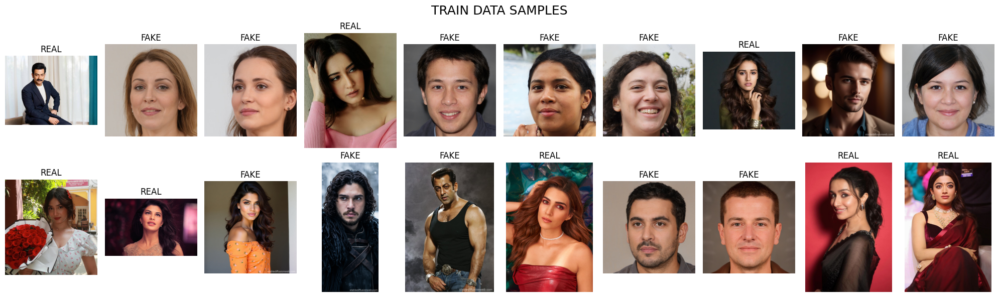

In [11]:
fig, axes = plt.subplots(
    2,
    10,
    figsize=(20, 6) # Adjusted figsize for 10 columns
)

sample_train = train_df.sample(20)

for i, (_, row) in enumerate(sample_train.iterrows()):

    img = cv2.imread(row.path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    label = (
        "REAL"
        if row.label == 0
        else "FAKE"
    )

    axes[i//10, i%10].imshow(img)

    axes[i//10, i%10].set_title(label)

    axes[i//10, i%10].axis("off")

plt.suptitle(
    "TRAIN DATA SAMPLES",
    fontsize=18
)

plt.tight_layout()

plt.show()

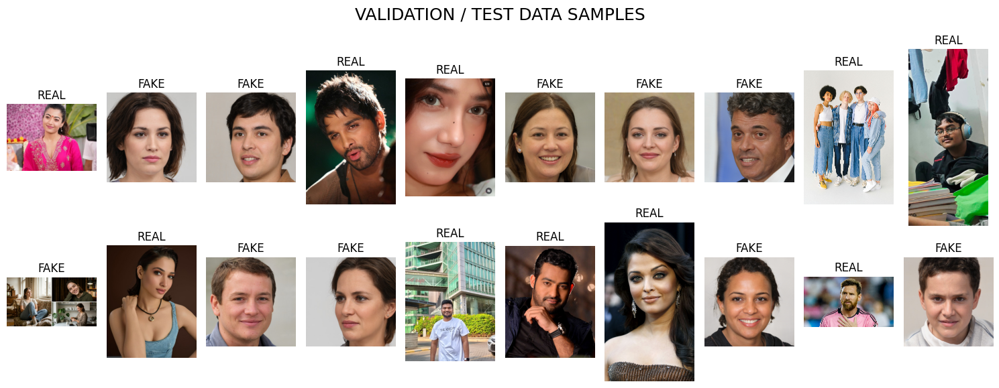

In [12]:
fig, axes = plt.subplots(
    2,
    10,
    figsize=(15,6)
)

sample_val = val_df.sample(20)

for i, (_, row) in enumerate(sample_val.iterrows()):

    img = cv2.imread(row.path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    label = (
        "REAL"
        if row.label == 0
        else "FAKE"
    )

    axes[i//10, i%10].imshow(img)

    axes[i//10, i%10].set_title(label)

    axes[i//10, i%10].axis("off")

plt.suptitle(
    "VALIDATION / TEST DATA SAMPLES",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [13]:
# =========================================================
# IMAGE SIZE
# =========================================================

IMAGE_SIZE = 380

In [14]:
# =========================================================
# SRM KERNEL
# =========================================================

SRM_KERNEL = np.array([

    [0, 0, 0, 0, 0],

    [0, -1, 2, -1, 0],

    [0, 2, -4, 2, 0],

    [0, -1, 2, -1, 0],

    [0, 0, 0, 0, 0]

], dtype=np.float32)

In [15]:
from torchvision import transforms

# =========================================================
# TRANSFORMS
# =========================================================

train_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]
    )
])

In [16]:
# =========================================================
# CUSTOM DATASET
# =========================================================

class DeepfakeDataset(Dataset):

    def __init__(

        self,

        dataframe,

        transform=None
    ):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def apply_srm(self,image):

        filtered = []

        for i in range(3):

            channel = cv2.filter2D(

                image[:,:,i],

                -1,

                SRM_KERNEL
            )

            filtered.append(channel)

        filtered = np.stack(

            filtered,

            axis=2
        )

        filtered = np.clip(

            filtered,

            0,

            255
        )

        return filtered.astype(np.uint8)

    def __getitem__(self,idx):

        row = self.df.iloc[idx]

        image = cv2.imread(row.path)

        image = cv2.cvtColor(

            image,

            cv2.COLOR_BGR2RGB
        )

        image = self.apply_srm(image)

        if self.transform:

            image = self.transform(image)

        label = torch.tensor(

            row.label,

            dtype=torch.float32
        )

        return image,label

In [17]:
# =========================================================
# DATALOADER
# =========================================================

train_dataset = DeepfakeDataset(

    train_df,

    transform=train_transform
)

val_dataset = DeepfakeDataset(

    val_df,

    transform=val_transform
)

train_loader = DataLoader(

    train_dataset,

    batch_size=8,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=8,

    shuffle=False
)

In [18]:
# =========================================================
# MODEL
# =========================================================

model = timm.create_model(

    "efficientnet_b4",

    pretrained=True,

    num_classes=1
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [19]:
# =========================================================
# LOSS + OPTIMIZER
# =========================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4
)

In [20]:
# =========================================================
# TRAINING HISTORY
# =========================================================

train_acc_history = []

val_acc_history = []

train_loss_history = []

val_loss_history = []

In [21]:
# =========================================================
# TRAINING LOOP
# =========================================================

EPOCHS = 10

best_acc = 0

for epoch in range(EPOCHS):

    print(f"\nEPOCH {epoch+1}/{EPOCHS}")

    # TRAIN
    model.train()

    train_loss = 0

    correct = 0

    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)

        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(

            outputs,

            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    # VALIDATION
    model.eval()

    val_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).float()

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    val_acc = correct / total

    train_acc_history.append(
        train_acc
    )

    val_acc_history.append(
        val_acc
    )

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    print()

    print("TRAIN ACC:", train_acc)

    print("VAL ACC:", val_acc)

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save({

            "model_state_dict":
            model.state_dict()

        },

        "/content/drive/MyDrive/custom_b4_srm.pth"
        )

        print("BEST MODEL SAVED")


EPOCH 1/10


100%|██████████| 105/105 [06:49<00:00,  3.90s/it]



TRAIN ACC: 0.7751196172248804
VAL ACC: 0.8666666666666667
BEST MODEL SAVED

EPOCH 2/10


100%|██████████| 105/105 [01:44<00:00,  1.00it/s]



TRAIN ACC: 0.8863636363636364
VAL ACC: 0.8714285714285714
BEST MODEL SAVED

EPOCH 3/10


...


TRAIN ACC: 0.9605263157894737
VAL ACC: 0.9238095238095239

EPOCH 9/10


100%|██████████| 105/105 [01:43<00:00,  1.02it/s]



TRAIN ACC: 0.9868421052631579
VAL ACC: 0.9142857142857143

EPOCH 10/10


100%|██████████| 105/105 [01:42<00:00,  1.03it/s]



TRAIN ACC: 0.9796650717703349
VAL ACC: 0.9142857142857143


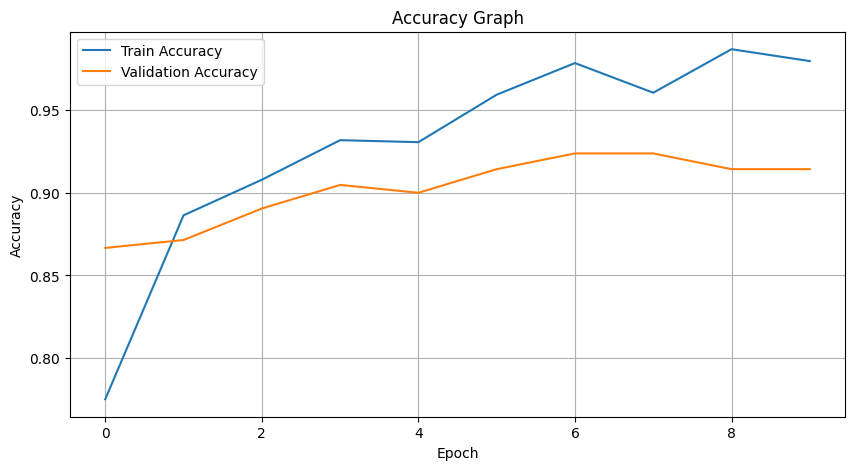

In [22]:
# =========================================================
# ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(
    train_acc_history,
    label="Train Accuracy"
)

plt.plot(
    val_acc_history,
    label="Validation Accuracy"
)

plt.title("Accuracy Graph")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

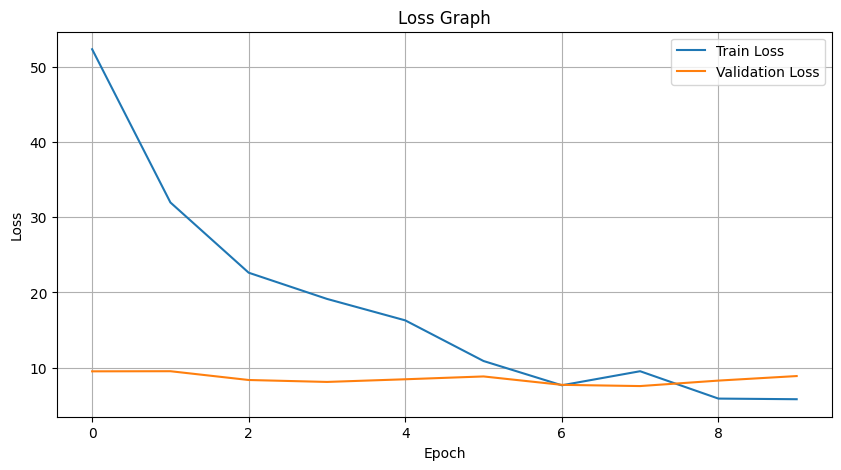

In [23]:
# =========================================================
# LOSS GRAPH
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(
    train_loss_history,
    label="Train Loss"
)

plt.plot(
    val_loss_history,
    label="Validation Loss"
)

plt.title("Loss Graph")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [24]:
# =========================================================
# EVALUATION
# =========================================================

all_preds = []

all_labels = []

wrong_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        for i in range(len(preds)):

            if preds[i] != labels[i]:

                wrong_predictions.append({

                    "image": images[i].cpu(),

                    "actual": labels[i].cpu().item(),

                    "predicted": preds[i].cpu().item()
                })

In [25]:
# =========================================================
# METRICS
# =========================================================

print("="*50)

print("MODEL METRICS")

print("="*50)

print()

print(
    "Accuracy :",
    accuracy_score(
        all_labels,
        all_preds
    )
)

print(
    "Precision :",
    precision_score(
        all_labels,
        all_preds
    )
)

print(
    "Recall :",
    recall_score(
        all_labels,
        all_preds
    )
)

print(
    "F1 Score :",
    f1_score(
        all_labels,
        all_preds
    )
)

MODEL METRICS

Accuracy : 0.9142857142857143
Precision : 0.9291338582677166
Recall : 0.9291338582677166
F1 Score : 0.9291338582677166


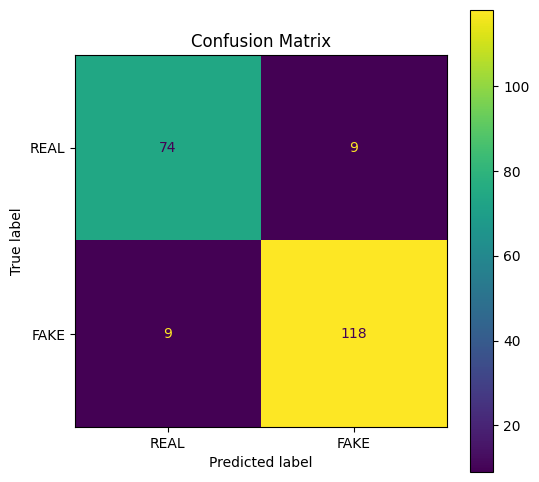

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["REAL","FAKE"]
)

fig, ax = plt.subplots(
    figsize=(6,6)
)

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

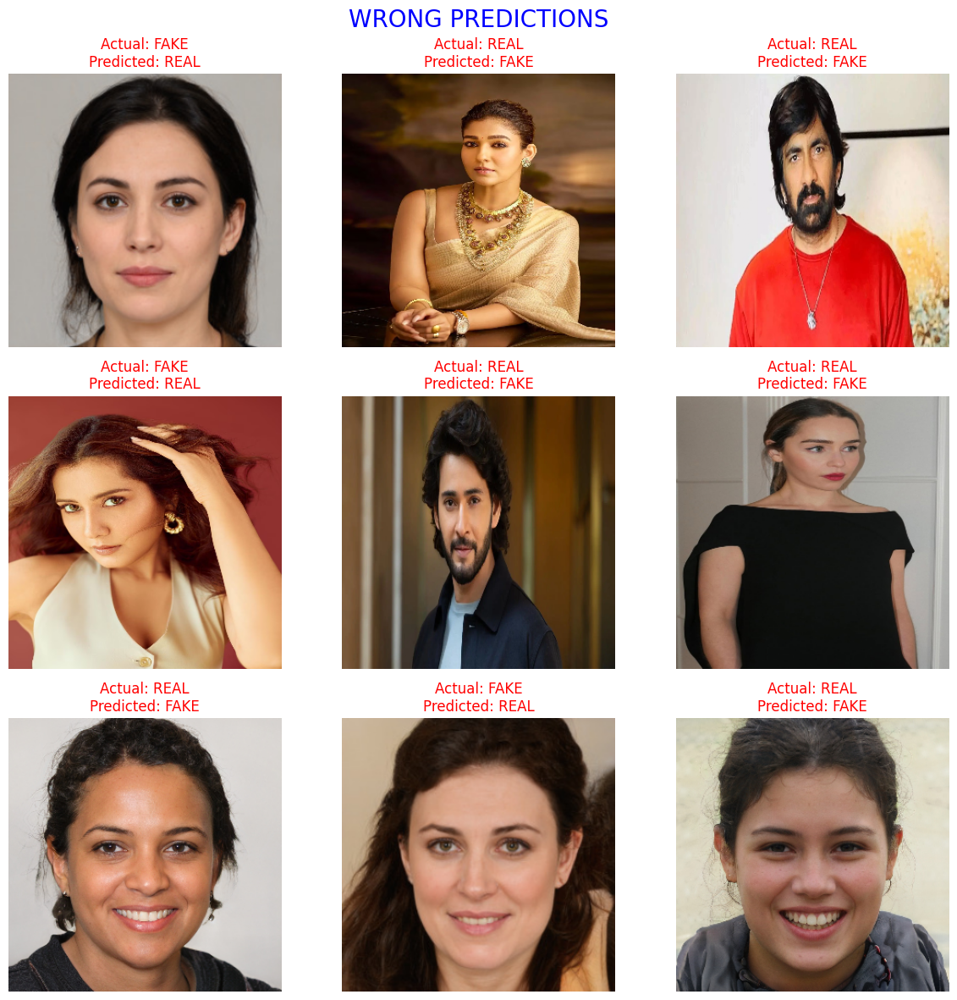

In [27]:
# =========================================================
# WRONG PREDICTIONS (COLORFUL)
# =========================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12,12)
)

for i in range(min(9, len(wrong_predictions))):

    item = wrong_predictions[i]

    img_path = val_df.iloc[i]["path"]

    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (300,300)
    )

    img = img.astype(np.float32) / 255.0

    actual = (
        "FAKE"
        if item["actual"] == 1
        else "REAL"
    )

    predicted = (
        "FAKE"
        if item["predicted"] == 1
        else "REAL"
    )

    axes[i//3, i%3].imshow(img)

    axes[i//3, i%3].set_title(

        f"Actual: {actual}\nPredicted: {predicted}",

        fontsize=12,

        color="red"
    )

    axes[i//3, i%3].axis("off")

plt.suptitle(

    "WRONG PREDICTIONS",

    fontsize=20,

    color="blue"
)

plt.tight_layout()

plt.show()

In [28]:
target_layers = [model.blocks[-2]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

def predict_image(image_path):

    # ============================================
    # ORIGINAL IMAGE
    # ============================================

    original = cv2.imread(image_path)

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    original_display = cv2.resize(
        original,
        (IMAGE_SIZE, IMAGE_SIZE) # Changed from (300,300) to (IMAGE_SIZE, IMAGE_SIZE)
    )

    # ============================================
    # SRM FILTER
    # ============================================

    filtered = []

    for i in range(3):

        channel = cv2.filter2D(

            original[:,:,i],

            -1,

            SRM_KERNEL
        )

        filtered.append(channel)

    srm_image = np.stack(
        filtered,
        axis=2
    )

    srm_image = np.clip(
        srm_image,
        0,
        255
    ).astype(np.uint8)

    # ============================================
    # TRANSFORM
    # ============================================

    transformed = val_transform(
        srm_image
    )

    tensor = transformed.unsqueeze(0).to(device)

    # ============================================
    # PREDICTION
    # ============================================

    model.eval()

    with torch.no_grad():

        output = model(tensor)

        prob = torch.sigmoid(
            output
        ).item()

    label = (
        "FAKE"
        if prob > 0.5
        else "REAL"
    )

    confidence = (
        prob
        if prob > 0.5
        else 1 - prob
    )

    print("="*40)

    print("DEEPFAKE DETECTION RESULT")

    print("="*40)

    print()

    print("PREDICTION :", label)

    print(
        "CONFIDENCE :",
        round(confidence,4)
    )

    print()

    print(
        "FAKE PROBABILITY :",
        round(prob,4)
    )

    print(
        "REAL PROBABILITY :",
        round(1-prob,4)
    )

    # ============================================
    # GRADCAM
    # ============================================

    grayscale_cam = cam(input_tensor=tensor)[0]

    # Explicitly resize grayscale_cam to match original_display dimensions
    grayscale_cam = cv2.resize(grayscale_cam, (original_display.shape[1], original_display.shape[0]))

    rgb_float = original_display.astype(
        np.float32
    ) / 255.0

    cam_image = show_cam_on_image(

        rgb_float,

        grayscale_cam,

        use_rgb=True
    )

    # ============================================
    # DISPLAY
    # ============================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,6)
    )

    axes[0].imshow(
        original_display
    )

    axes[0].set_title(
        "Original Image",
        fontsize=15
    )

    axes[0].axis("off")

    axes[1].imshow(
        cam_image
    )

    axes[1].set_title(
        f"GradCAM - {label}",
        fontsize=15
    )

    axes[1].axis("off")

    plt.tight_layout()

    plt.show()

DEEPFAKE DETECTION RESULT

PREDICTION : FAKE
CONFIDENCE : 0.9957

FAKE PROBABILITY : 0.9957
REAL PROBABILITY : 0.0043


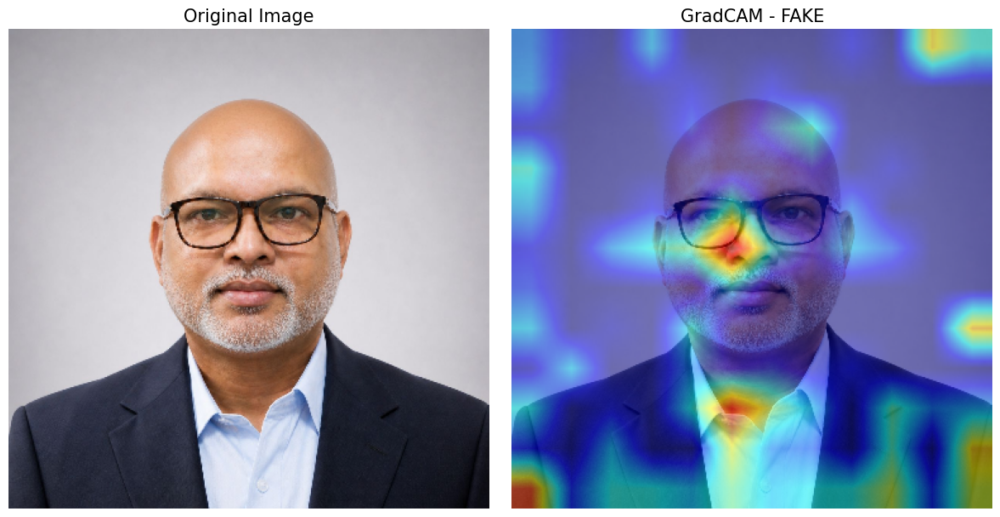

In [30]:
predict_image("/content/boss.jpeg")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.5073

FAKE PROBABILITY : 0.4927
REAL PROBABILITY : 0.5073


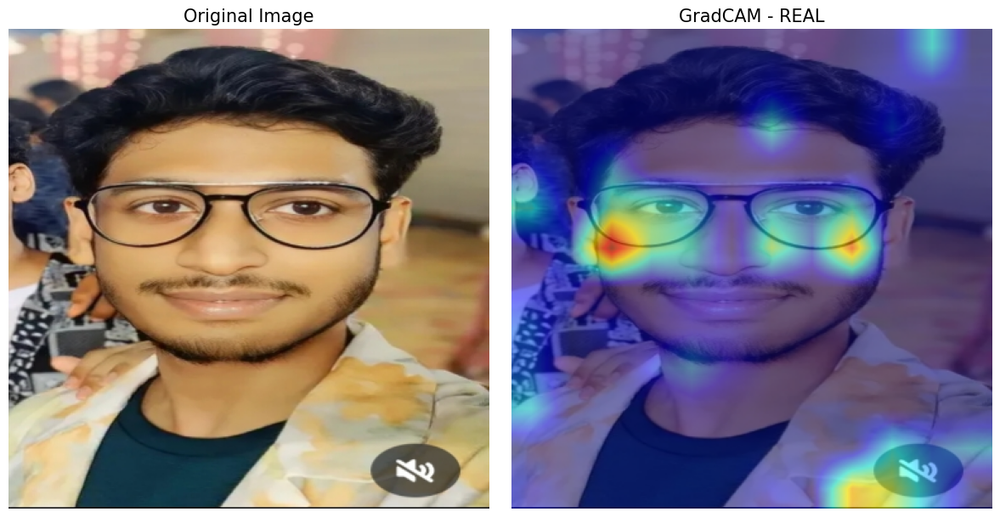

In [33]:
predict_image("/content/003.jpeg")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.9968

FAKE PROBABILITY : 0.0032
REAL PROBABILITY : 0.9968


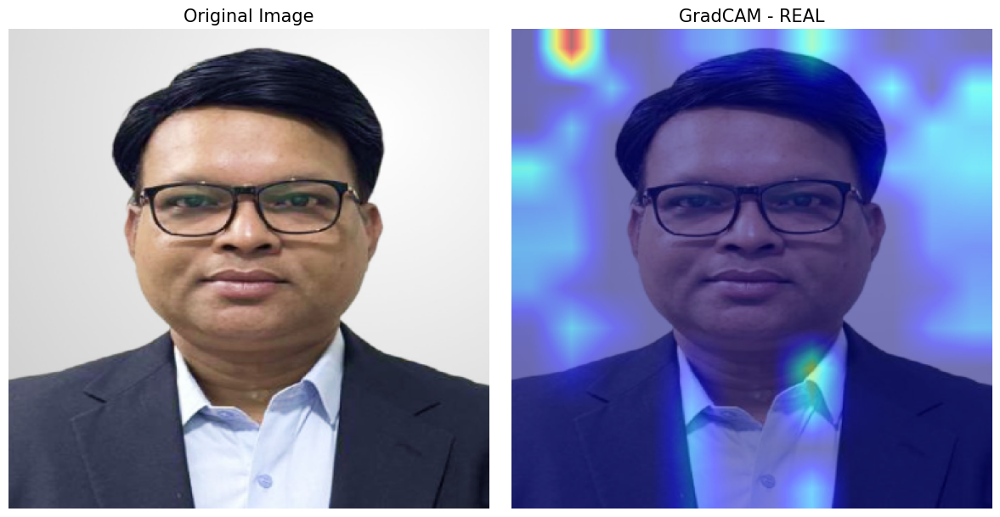

In [34]:
predict_image("/content/004.jpeg")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.9696

FAKE PROBABILITY : 0.0304
REAL PROBABILITY : 0.9696


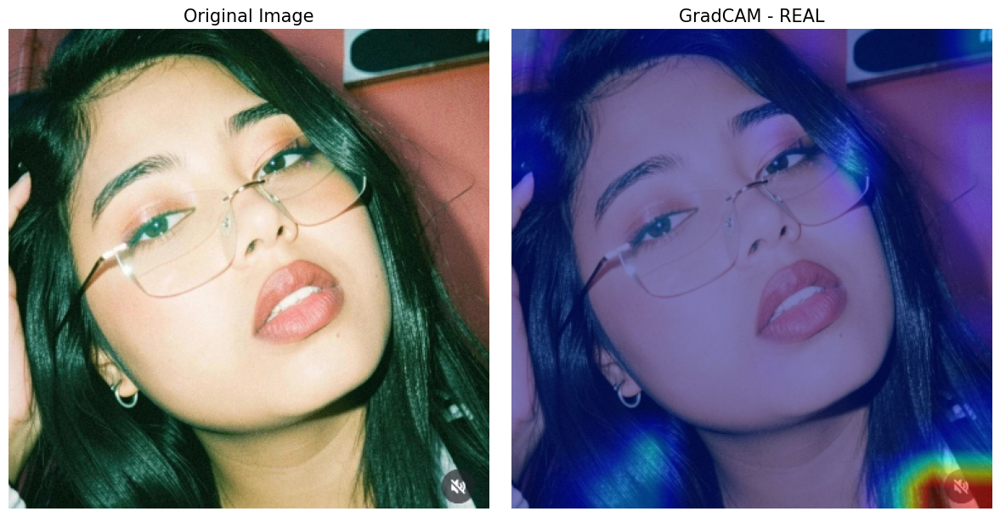

In [35]:
predict_image("/content/005.jpeg")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.9791

FAKE PROBABILITY : 0.0209
REAL PROBABILITY : 0.9791


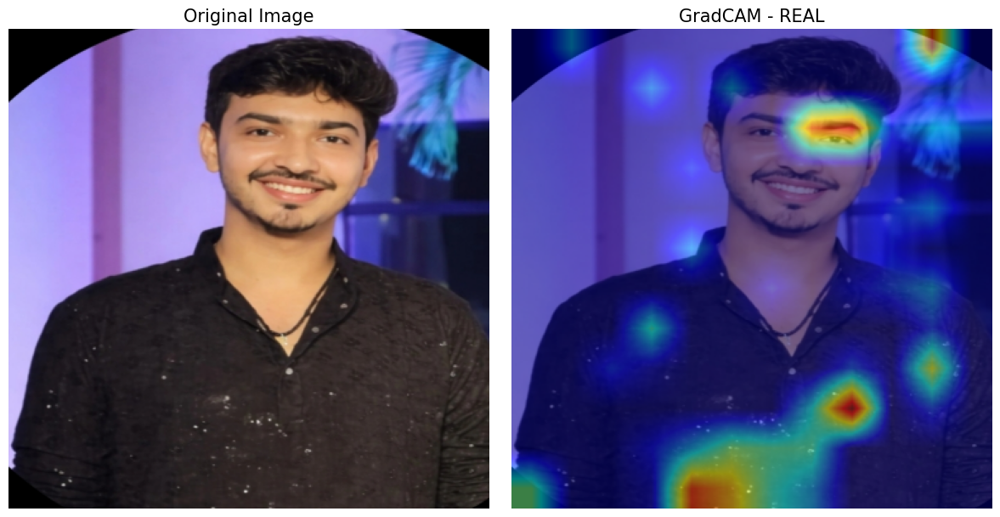

In [31]:
predict_image("/content/008.jpeg")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.7914

FAKE PROBABILITY : 0.2086
REAL PROBABILITY : 0.7914


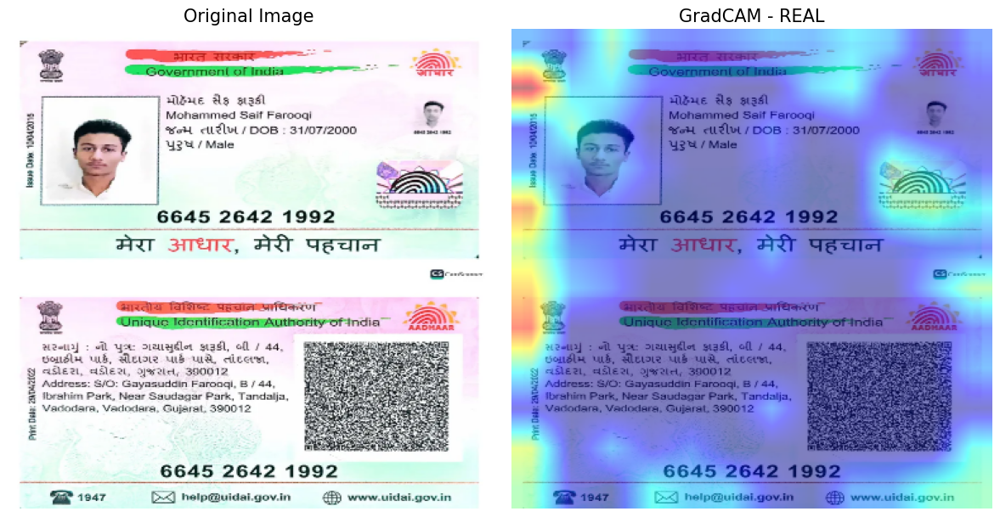

In [38]:
predict_image("/content/009.webp")

In [37]:
torch.save({
    "model_state_dict": model.state_dict()
}, "/content/drive/MyDrive/custom_b4_srm01.pth")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.6731

FAKE PROBABILITY : 0.3269
REAL PROBABILITY : 0.6731


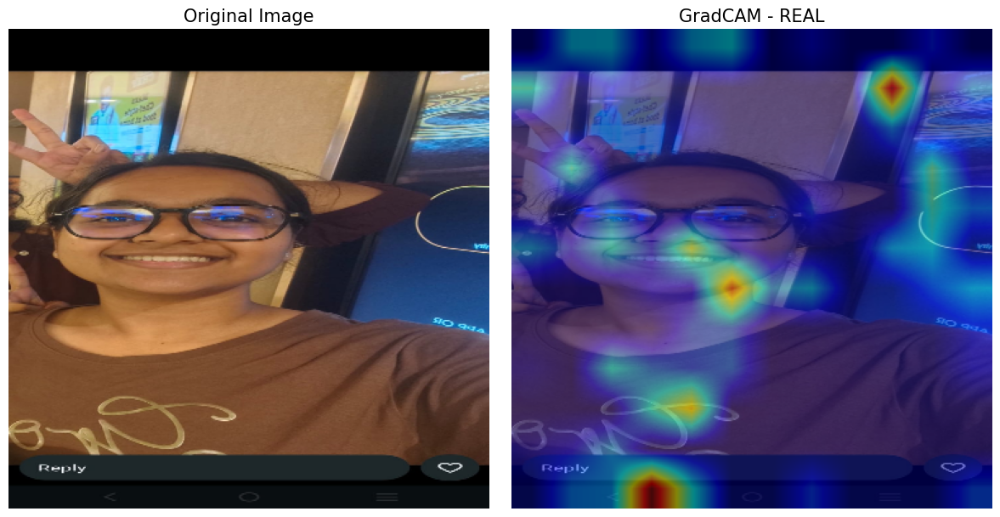

In [41]:
predict_image("/content/12.jpeg")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.998

FAKE PROBABILITY : 0.002
REAL PROBABILITY : 0.998


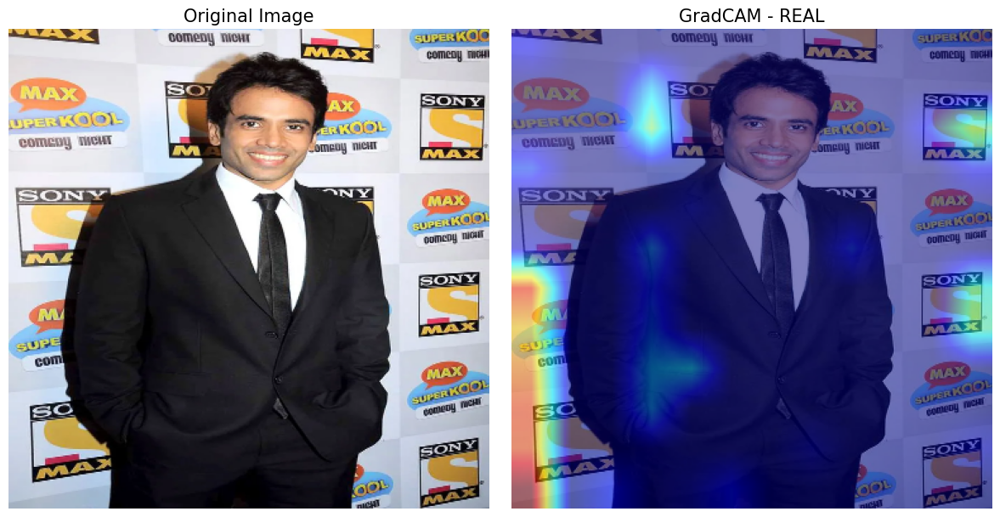

In [43]:
predict_image("/content/tt.webp")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.9991

FAKE PROBABILITY : 0.0009
REAL PROBABILITY : 0.9991


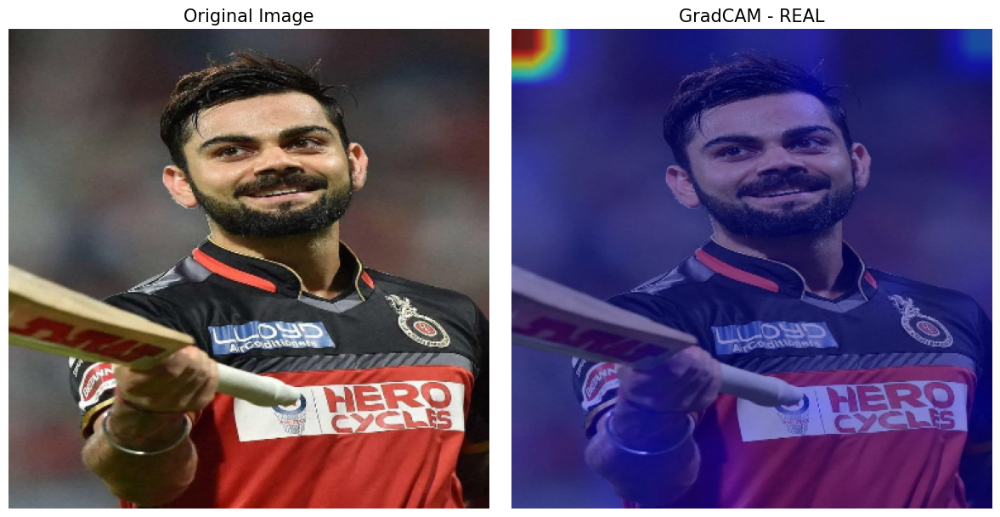

In [45]:
predict_image("/content/vv.webp")

DEEPFAKE DETECTION RESULT

PREDICTION : REAL
CONFIDENCE : 0.966

FAKE PROBABILITY : 0.034
REAL PROBABILITY : 0.966


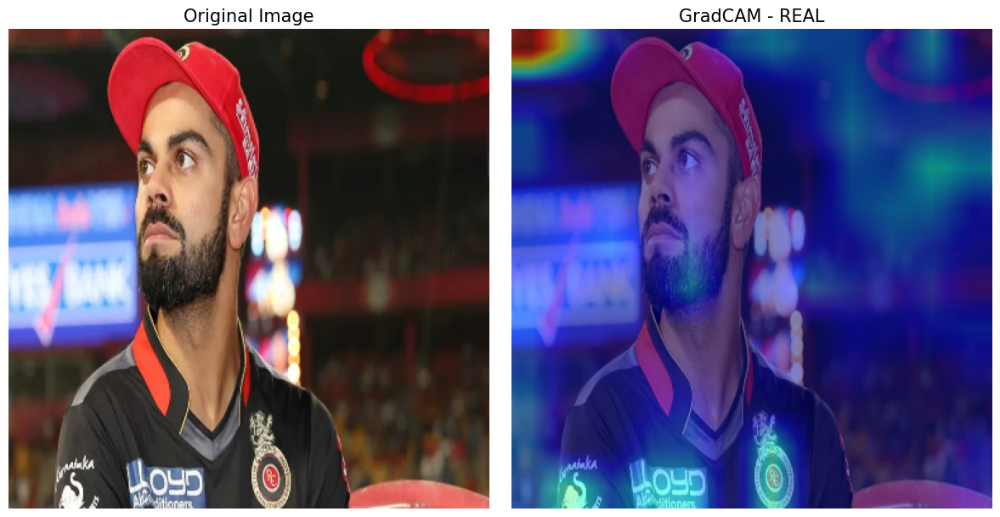

In [46]:
predict_image("/content/vk.webp")